# Next Word Predictor 


# Import Required Libraries

In [1]:
from collections import Counter, defaultdict
import math
import random
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

seed = 42
random.seed(seed)

# Create Manual Dataset

In [2]:
sentences = [
    "machine learning models learn patterns",
    "large language models predict tokens",
    "language models learn from text",
    "machine learning powers language applications",
    "models predict the next token",
]

corpus = pd.DataFrame({"sentence": sentences})
corpus["word_count"] = corpus["sentence"].str.split().str.len()

display(corpus)
print("Total sentences:", len(corpus))
print("Total words:", corpus["word_count"].sum())

,sentence,word_count
0,machine learning models learn patterns,5
1,large language models predict tokens,5
2,language models learn from text,5
3,machine learning powers language applications,5
4,models predict the next token,5


Total sentences: 5
Total words: 25


# Tokenize Input Text

In [3]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())


print(tokenize("Language models predict tokens!"))

['language', 'models', 'predict', 'tokens']


# Define Bigram Model

In [4]:
class BigramLanguageModel:
    START_TOKEN = "<s>"
    END_TOKEN = "</s>"

    def __init__(self, alpha=1.0):
        if alpha <= 0:
            raise ValueError("alpha must be greater than 0")

        self.alpha = alpha
        self.bigram_counts = defaultdict(Counter)
        self.word_counts = Counter()
        self.vocabulary = []

    def fit(self, sentences):
        vocabulary = set()
        self.bigram_counts = defaultdict(Counter)
        self.word_counts = Counter()

        for sentence in sentences:
            words = tokenize(sentence)

            # Sentence markers help the model learn beginnings and endings
            tokens = [self.START_TOKEN] + words + [self.END_TOKEN]
            vocabulary.update(words)
            vocabulary.add(self.END_TOKEN)

            for current_word, next_word in zip(tokens, tokens[1:]):
                self.bigram_counts[current_word][next_word] += 1
                self.word_counts[current_word] += 1

        self.vocabulary = sorted(vocabulary)
        return self

    def probability(self, current_word, next_word):
        pair_count = self.bigram_counts.get(current_word, {}).get(next_word, 0)
        current_count = self.word_counts.get(current_word, 0)

        # Add-alpha smoothing prevents unseen pairs from getting zero probability
        numerator = pair_count + self.alpha
        denominator = current_count + self.alpha * len(self.vocabulary)
        return numerator / denominator

    def predict_next(self, current_word, top_k=5, include_end=False):
        current_word = current_word.lower()
        candidates = [
            word for word in self.vocabulary
            if include_end or word != self.END_TOKEN
        ]

        predictions = [
            (word, self.probability(current_word, word))
            for word in candidates
        ]
        predictions.sort(key=lambda item: (-item[1], item[0]))

        return predictions[:top_k]

    def generate(self, seed_word=None, max_words=10, strategy="greedy", seed=42):
        rng = random.Random(seed)
        current_word = self.START_TOKEN if seed_word is None else seed_word.lower()
        generated_words = [] if seed_word is None else [current_word]

        for _ in range(max_words - len(generated_words)):
            choices = [
                (word, self.probability(current_word, word))
                for word in self.vocabulary
            ]

            if strategy == "sample":
                words, probabilities = zip(*choices)
                next_word = rng.choices(words, weights=probabilities, k=1)[0]
            else:
                next_word = max(choices, key=lambda item: item[1])[0]

            if next_word == self.END_TOKEN:
                break

            generated_words.append(next_word)
            current_word = next_word

        return " ".join(generated_words)

    def perplexity(self, sentence):
        tokens = [self.START_TOKEN] + tokenize(sentence) + [self.END_TOKEN]
        log_probability = 0

        for current_word, next_word in zip(tokens, tokens[1:]):
            probability = self.probability(current_word, next_word)
            log_probability += math.log(probability)

        transitions = len(tokens) - 1
        return math.exp(-log_probability / transitions)

# Train Language Model

In [5]:
model = BigramLanguageModel(alpha=1.0)
model.fit(sentences)

print("Vocabulary size:", len(model.vocabulary))
print("Vocabulary:", model.vocabulary)

Vocabulary size: 17
Vocabulary: ['</s>', 'applications', 'from', 'language', 'large', 'learn', 'learning', 'machine', 'models', 'next', 'patterns', 'powers', 'predict', 'text', 'the', 'token', 'tokens']


# Review Learned Transitions

In [6]:
transition_rows = []

for current_word, next_words in model.bigram_counts.items():
    for next_word, count in next_words.items():
        transition_rows.append({
            "current_word": current_word,
            "next_word": next_word,
            "count": count,
            "probability": model.probability(current_word, next_word),
        })

transitions = pd.DataFrame(transition_rows)
transitions = transitions.sort_values(
    ["count", "current_word", "next_word"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(transitions.head(15))

,current_word,next_word,count,probability
0,<s>,machine,2,0.136364
1,language,models,2,0.150000
2,machine,learning,2,0.157895
3,models,learn,2,0.142857
4,models,predict,2,0.142857
5,<s>,language,1,0.090909
6,<s>,large,1,0.090909
7,<s>,models,1,0.090909
8,applications,</s>,1,0.111111
9,from,text,1,0.111111


# Check Example Probabilities

In [7]:
examples = [
    ("language", "models"),
    ("language", "applications"),
    ("models", "predict"),
    ("models", "tokens"),
]

probability_examples = pd.DataFrame([
    {
        "current_word": current_word,
        "next_word": next_word,
        "count": model.bigram_counts[current_word][next_word],
        "probability": model.probability(current_word, next_word),
    }
    for current_word, next_word in examples
])

display(probability_examples)

,current_word,next_word,count,probability
0,language,models,2,0.150000
1,language,applications,1,0.100000
2,models,predict,2,0.142857
3,models,tokens,0,0.047619


# Predict Next Words

In [8]:
def prediction_table(current_word, top_k=5):
    predictions = model.predict_next(current_word, top_k)
    table = pd.DataFrame(predictions, columns=["next_word", "probability"])
    table.insert(0, "current_word", current_word)
    table["probability_percent"] = table["probability"] * 100
    return table


query_words = ["language", "models", "machine", "unseen"]

all_predictions = pd.concat(
    [prediction_table(word, top_k=3) for word in query_words],
    ignore_index=True,
)

display(all_predictions)

,current_word,next_word,probability,probability_percent
0,language,models,0.150000,15.000000
1,language,applications,0.100000,10.000000
2,language,from,0.050000,5.000000
3,models,learn,0.142857,14.285714
4,models,predict,0.142857,14.285714
5,models,applications,0.047619,4.761905
6,machine,learning,0.157895,15.789474
7,machine,applications,0.052632,5.263158
8,machine,from,0.052632,5.263158
9,unseen,applications,0.058824,5.882353


# Visualize Word Predictions

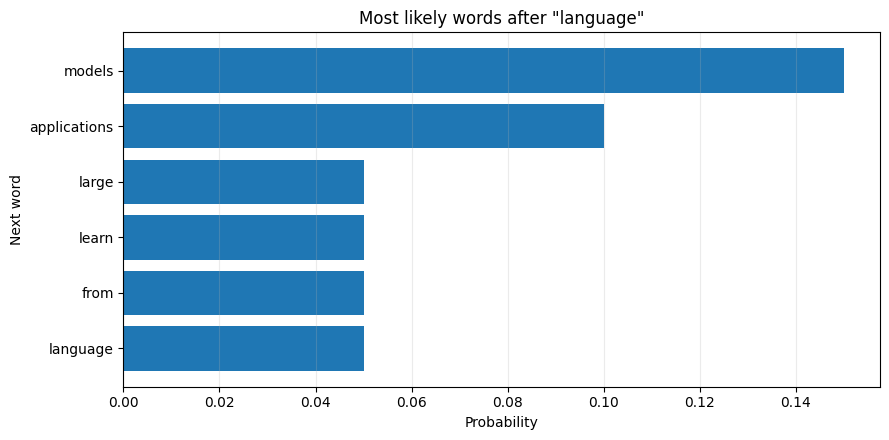

In [9]:
language_predictions = prediction_table("language", top_k=6)
plot_data = language_predictions.sort_values("probability")

plt.figure(figsize=(9, 4.5))
plt.barh(plot_data["next_word"], plot_data["probability"])
plt.title('Most likely words after "language"')
plt.xlabel("Probability")
plt.ylabel("Next word")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Generate Sample Text

In [10]:
generated_text = pd.DataFrame([
    {
        "strategy": "greedy",
        "seed_word": "machine",
        "result": model.generate("machine", strategy="greedy"),
    },
    {
        "strategy": "sample",
        "seed_word": "language",
        "result": model.generate(
            "language",
            strategy="sample",
            seed=seed,
        ),
    },
    {
        "strategy": "greedy",
        "seed_word": "sentence start",
        "result": model.generate(strategy="greedy"),
    },
])

display(generated_text)

,strategy,seed_word,result
0,greedy,machine,machine learning models learn from text
1,sample,language,language next
2,greedy,sentence start,machine learning models learn from text


# Evaluate Model Performance

In [11]:
evaluation_sentences = [
    "language models predict tokens",
    "machine learning models predict tokens",
    "models learn from text",
    "machine learning powers applications",
]

evaluation = pd.DataFrame({
    "sentence": evaluation_sentences,
    "perplexity": [
        model.perplexity(sentence)
        for sentence in evaluation_sentences
    ],
}).sort_values("perplexity")

display(evaluation)
print("Average perplexity:", round(evaluation["perplexity"].mean(), 4))

,sentence,perplexity
1,machine learning models predict tokens,8.009774
0,language models predict tokens,8.481509
2,models learn from text,9.006164
3,machine learning powers applications,9.350492


Average perplexity: 8.712
